# **Heart Failure Mortality Risk Analysis**

## **Introduction**

Healthcare organizations increasingly use clinical analytics to identify patients who may require closer monitoring and additional support. This analysis examines a dataset of 299 patients with heart failure to understand which demographic, clinical, and comorbidity characteristics are associated with mortality during follow-up.

This cardiology service company is evaluating whether routinely collected patient characteristics can support a risk-stratification initiative for patients with heart failure. This analysis evaluates patterns in the data, identifies characteristics associated with higher observed mortality, and assesses whether those characteristics can support a practical risk-stratification framework.

**Healthcare Questions**

* What does the mortality population look like?
* Which patient characteristics show the largest differences between patients who died and patients who survived?
* How does observed mortality vary across clinically meaningful patient segments?
* Does the relationship between age and mortality change across levels of cardiac function?
* Which combination of patient characteristics defines the highest observed risk segment?


**Who is reading this analysis?**

* The directors of cardiology who are determined to identify higher-risk patient groups and potentially implement a risk-stratification initiative if justified.
* Healthcare/Clinical analysts who care about which variables matter, the model performance, and the reproducibility of this analysis.



---


## **Preparing the Environment**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_curve,
    auc
)


SEED = 42
np.random.seed(SEED)

In [ ]:
#upload the data file (.csv) from the github repo into the Colab before running

df = pd.read_csv('/heart_failure_clinical_records_dataset.csv')



---

##**Data Exploration**

In [ ]:
df.head()

,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death
0,1,75.0,0,582,0,20,1,265000.00,1.9,1,0,1
1,2,55.0,0,7861,0,38,0,263358.03,1.1,1,0,1
2,3,65.0,0,146,0,20,0,162000.00,1.3,1,1,1
3,4,50.0,1,111,0,20,0,210000.00,1.9,1,0,1
4,5,65.0,1,160,1,20,0,327000.00,2.7,0,0,1


In [ ]:
df.tail()

,S no.,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,sex,smoking,death
294,295,62.0,0,61,1,38,1,155000.0,1.1,1,1,0
295,296,55.0,0,1820,0,38,0,270000.0,1.2,0,0,0
296,297,45.0,0,2060,1,60,0,742000.0,0.8,0,0,0
297,298,45.0,0,2413,0,38,0,140000.0,1.4,1,1,0
298,299,50.0,0,196,0,45,0,395000.0,1.6,1,1,0


In [ ]:
df.shape

(299, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S no.                     299 non-null    int64  
 1   age                       299 non-null    float64
 2   anaemia                   299 non-null    int64  
 3   creatinine phosphokinase  299 non-null    int64  
 4   diabetes                  299 non-null    int64  
 5   ejection fraction         299 non-null    int64  
 6   high bp                   299 non-null    int64  
 7   platelets                 299 non-null    float64
 8   serum creatinine          299 non-null    float64
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  death                     299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


You can easily tell there is a mix of categorical and numerical variables. Each row represents an individuals information and diagnosis during their check-up at the doctors. The columns within the dataset include demographic information (age and sex), clinical measurements (ejection fraction, serum creatinine, serum sodium, and platelets), and medical conditions in patients (diabetes, smoking, anaemia, and high blood pressure). In total there are 299 rows and 12 columns.

---

## **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
S no.,0
age,0
anaemia,0
creatinine phosphokinase,0
diabetes,0
ejection fraction,0
high bp,0
platelets,0
serum creatinine,0
sex,0


We see that the data set contains no null values.

In [ ]:
df.duplicated().sum()

np.int64(0)

We see that there are no duplicate values, hence our dataset is good to analyze.

---

## **Exploratory Data Analysis**

### **1. How large is the mortality population, and what does the baseline patient population look like?**

In [ ]:
outcome_summary = (
    df["Outcome"]
    .value_counts()
    .reindex(["Survived", "Died"])
    .rename_axis("Outcome")
    .reset_index(name="Patients")
)

outcome_summary["Percentage"] = (
    outcome_summary["Patients"] / len(df) * 100
).round(1)

outcome_summary


,Outcome,Patients,Percentage
0,Survived,203,67.9
1,Died,96,32.1


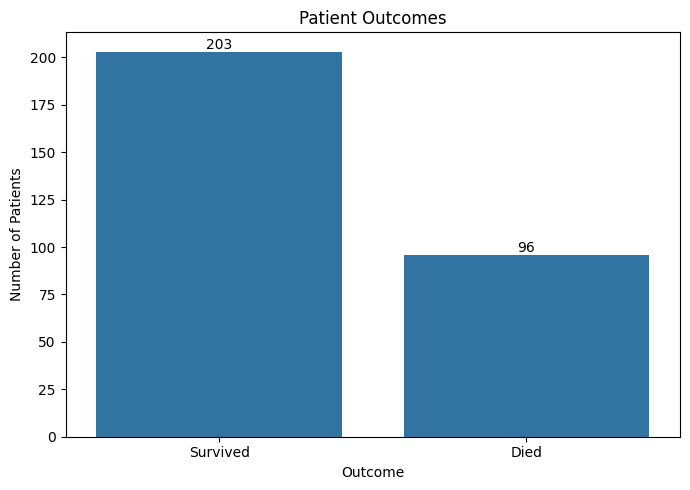

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Outcome",
    order=["Survived", "Died"]
)

plt.title("Patient Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

We see that from the 299 patients within the dataset, 203 survived and 96 died corresponding to an observed mortality rate of 32.1%, meaning approximately one in three patients in the sample died. While the people that survived to represent the larger proportion of the group, the deaths still account for a substantial portion of the sample.

### **2. Which baseline clinical characteristics show the clearest differences between patients who survived and patients who died?**

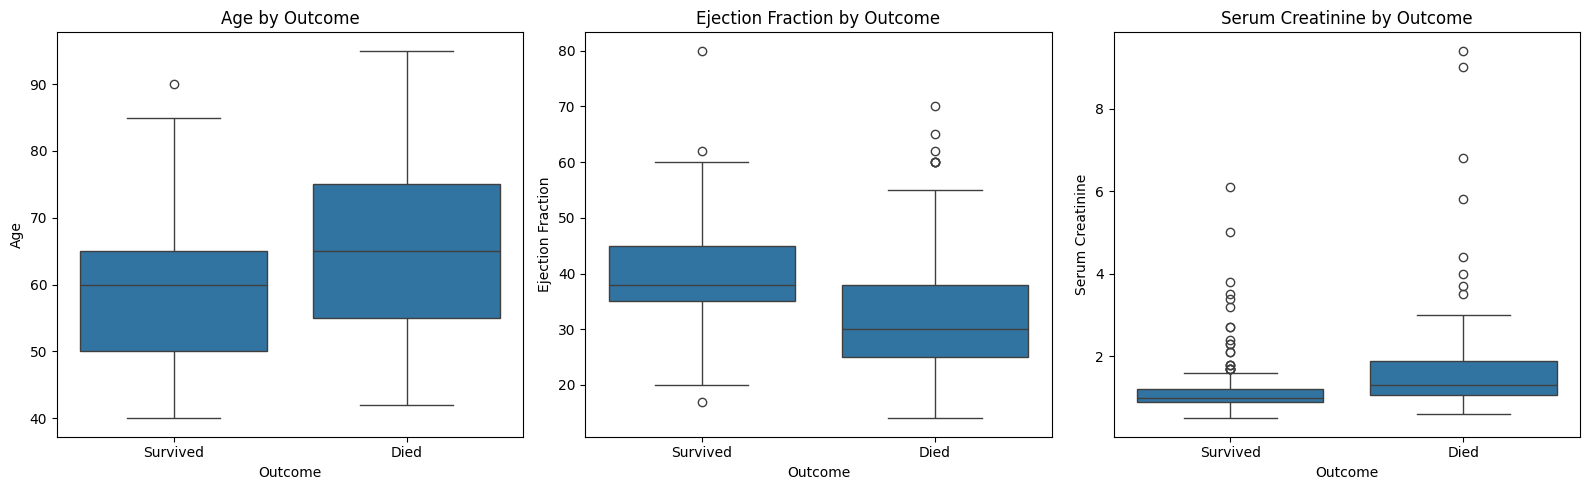

In [ ]:
features_to_compare = [
    "age",
    "ejection fraction",
    "serum creatinine"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

for ax, feature in zip(axes, features_to_compare):

    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature,
        order=["Survived", "Died"],
        ax=ax
    )

    ax.set_title(
        f"{feature.replace('_', ' ').title()} by Outcome"
    )

    ax.set_xlabel("Outcome")
    ax.set_ylabel(
        feature.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()

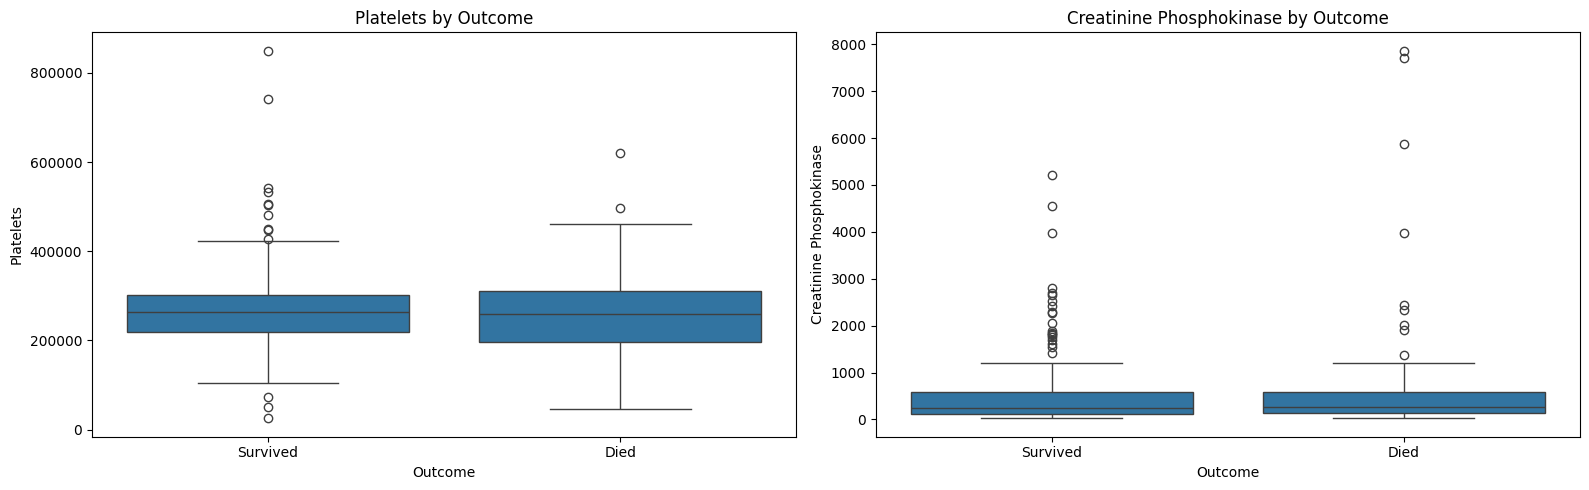

In [ ]:
features_to_compare = [
    "platelets",
    "creatinine phosphokinase"
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5)
)

for ax, feature in zip(axes, features_to_compare):

    sns.boxplot(
        data=df,
        x="Outcome",
        y=feature,
        order=["Survived", "Died"],
        ax=ax
    )

    ax.set_title(
        f"{feature.replace('_', ' ').title()} by Outcome"
    )

    ax.set_xlabel("Outcome")
    ax.set_ylabel(
        feature.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()

In [ ]:
features = [
    "age",
    "ejection fraction",
    "serum creatinine",
    "platelets",
    "creatinine phosphokinase"
]

comparison = []

for feature in features:

    survived = df.loc[
        df["death"] == 0, feature
    ]

    died = df.loc[
        df["death"] == 1, feature
    ]

    comparison.append({
        "Feature": feature,
        "Survived Median": survived.median(),
        "Died Median": died.median(),
        "Median Difference": died.median() - survived.median(),
        "Survived IQR": survived.quantile(0.75) - survived.quantile(0.25),
        "Died IQR": died.quantile(0.75) - died.quantile(0.25)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Feature,Survived Median,Died Median,Median Difference,Survived IQR,Died IQR
0,age,60.0,65.0,5.0,15.0,20.000
1,ejection fraction,38.0,30.0,-8.0,10.0,13.000
2,serum creatinine,1.0,1.3,0.3,0.3,0.825
3,platelets,263000.0,258500.0,-4500.0,82500.0,113500.000
4,creatinine phosphokinase,245.0,259.0,14.0,473.0,453.250


The largest differences between survivors and patients who died appear in age, ejection fraction, and serum creatinine. Patients who died had a higher median age (65 vs. 60), a lower median ejection fraction (30 vs. 38), and a higher median serum creatinine (1.3 vs. 1.0). Serum sodium also showed a smaller difference, with a lower median among patients who died. In contrast, platelet count and creatinine phosphokinase showed substantial overlap between the two groups and relatively small differences in their medians.

### **3. How does observed mortality vary across clinically meaningful patient segments?**

In [ ]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0, 64, 74, np.inf],
    labels=["Under 65", "65–74", "75+"]
)

df["EF_Group"] = pd.cut(
    df["ejection fraction"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["<30%", "30–39%", "40–49%", "50%+"]
)

df["Creatinine_Group"] = pd.cut(
    df["serum creatinine"],
    bins=[0, 0.99, 1.49, np.inf],
    labels=["<1.0", "1.0–1.49", "1.5+"]
)

def mortality_by_segment(data, segment):

    result = (
        data.groupby(segment, observed=False)["death"]
        .agg(
            Patients="count",
            Deaths="sum",
            Mortality_Rate="mean"
        )
        .reset_index()
    )

    result["Mortality_Rate"] = (
        result["Mortality_Rate"] * 100
    ).round(1)

    return result


In [ ]:
mortality_by_segment(df, "Age_Group")

,Age_Group,Patients,Deaths,Mortality_Rate
0,Under 65,184,46,25.0
1,65–74,74,25,33.8
2,75+,41,25,61.0


In [ ]:
mortality_by_segment(df, "EF_Group")

,EF_Group,Patients,Deaths,Mortality_Rate
0,<30%,59,38,64.4
1,30–39%,123,35,28.5
2,40–49%,57,9,15.8
3,50%+,60,14,23.3


In [ ]:
mortality_by_segment(df, "Creatinine_Group")

,Creatinine_Group,Patients,Deaths,Mortality_Rate
0,<1.0,81,9,11.1
1,1.0–1.49,146,42,28.8
2,1.5+,72,45,62.5


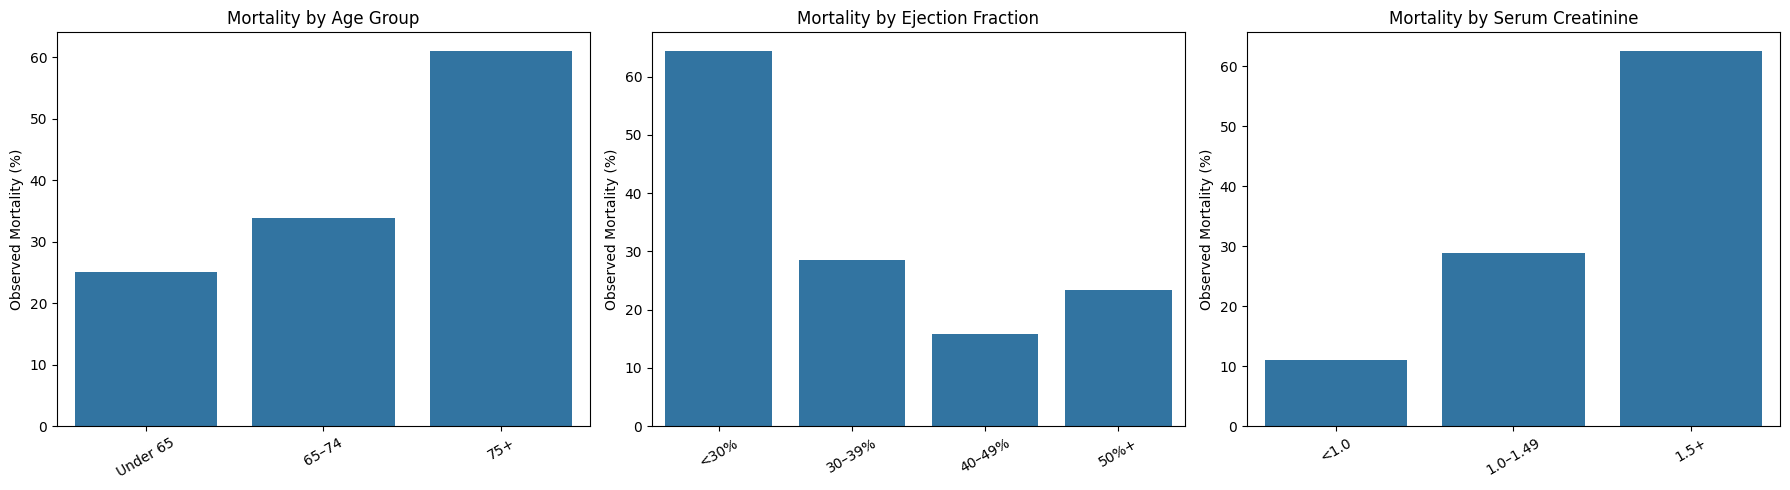

In [ ]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

segments = [
    ("Age_Group", "Mortality by Age Group"),
    ("EF_Group", "Mortality by Ejection Fraction"),
    ("Creatinine_Group", "Mortality by Serum Creatinine")
]

for ax, (column, title) in zip(axes, segments):

    summary = mortality_by_segment(df, column)

    sns.barplot(
        data=summary,
        x=column,
        y="Mortality_Rate",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Observed Mortality (%)")

    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Observed mortality varies substantially across age, ejection fraction, and serum creatinine segments. Patients aged 75 and older had an observed mortality rate of 61.0%, compared with 25.0% among patients under 65. The largest separation appears in ejection fraction and serum creatinine: mortality was 64.4% among patients with an ejection fraction below 30%, compared with 15.8% among those with an ejection fraction between 40% and 49%. Similarly, patients with serum creatinine of 1.5 or higher had an observed mortality rate of 62.5%, compared with 11.1% among patients below 1.0.

### **4. Does the relationship between age and mortality change across levels of cardiac function?**

In [ ]:
df["EF_Function"] = pd.cut(
    df["ejection fraction"],
    bins=[0, 39, np.inf],
    labels=["Lower EF (<40%)", "Higher EF (40%+)"]
)

In [ ]:
age_ef_summary = (
    df.groupby(
        ["Age_Group", "EF_Function"],
        observed=False
    )["death"]
    .agg(
        Patients="count",
        Deaths="sum",
        Mortality_Rate="mean"
    )
    .reset_index()
)

age_ef_summary["Mortality_Rate"] = (
    age_ef_summary["Mortality_Rate"] * 100
).round(1)

age_ef_summary

,Age_Group,EF_Function,Patients,Deaths,Mortality_Rate
0,Under 65,Lower EF (<40%),114,38,33.3
1,Under 65,Higher EF (40%+),70,8,11.4
2,65–74,Lower EF (<40%),45,18,40.0
3,65–74,Higher EF (40%+),29,7,24.1
4,75+,Lower EF (<40%),23,17,73.9
5,75+,Higher EF (40%+),18,8,44.4


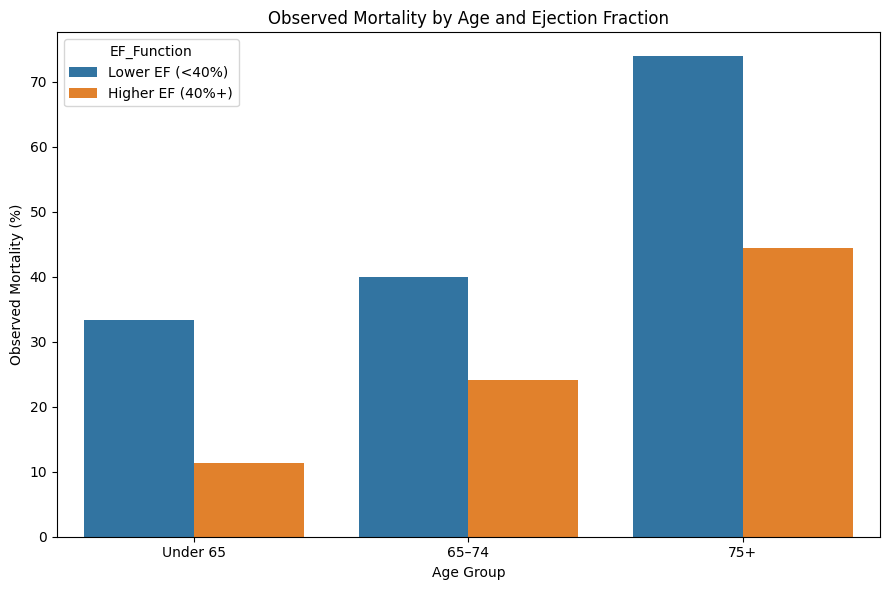

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=age_ef_summary,
    x="Age_Group",
    y="Mortality_Rate",
    hue="EF_Function"
)

plt.title(
    "Observed Mortality by Age and Ejection Fraction"
)

plt.xlabel("Age Group")
plt.ylabel("Observed Mortality (%)")

plt.tight_layout()
plt.show()

The relationship between age and observed mortality appears to vary across levels of cardiac function. Within every age group, patients with lower ejection fraction (<40%) had higher observed mortality than patients with higher ejection fraction ≥40%. The difference was particularly pronounced among patients aged 75 and older, where observed mortality was 73.9% for the lower-EF group compared with 44.4% for the higher-EF group. Among patients under 65, the corresponding rates were 33.3% and 11.4%. This suggests that age and cardiac function should not necessarily be considered independently when segmenting patients.

### **5. Which combination of patient characteristics defines the highest observed-risk segment?**

In [ ]:
risk_segments = (
    df.groupby(
        ["Age_Group", "EF_Function", "Creatinine_Group"],
        observed=False
    )["death"]
    .agg(
        Patients="count",
        Deaths="sum",
        Mortality_Rate="mean"
    )
    .reset_index()
)

risk_segments["Mortality_Rate"] = (
    risk_segments["Mortality_Rate"] * 100
).round(1)

# Remove very small groups
risk_segments_filtered = risk_segments[
    risk_segments["Patients"] >= 10
].copy()

risk_segments_filtered = (
    risk_segments_filtered
    .sort_values(
        "Mortality_Rate",
        ascending=False
    )
)

risk_segments_filtered

,Age_Group,EF_Function,Creatinine_Group,Patients,Deaths,Mortality_Rate
14,75+,Lower EF (<40%),1.5+,12,11,91.7
8,65–74,Lower EF (<40%),1.5+,12,8,66.7
2,Under 65,Lower EF (<40%),1.5+,29,16,55.2
5,Under 65,Higher EF (40%+),1.5+,10,5,50.0
16,75+,Higher EF (40%+),1.0–1.49,12,5,41.7
7,65–74,Lower EF (<40%),1.0–1.49,27,9,33.3
1,Under 65,Lower EF (<40%),1.0–1.49,52,16,30.8
10,65–74,Higher EF (40%+),1.0–1.49,17,5,29.4
0,Under 65,Lower EF (<40%),<1.0,33,6,18.2
4,Under 65,Higher EF (40%+),1.0–1.49,31,2,6.5


Within this sample, 11 of the 12 patients in the 75+ / EF <40% / serum creatinine ≥1.5 segment experienced a recorded death event, corresponding to an observed mortality rate of 91.7%. The highest observed-mortality segment combines three characteristics that individually showed strong differences across outcomes: older age, lower ejection fraction, and elevated serum creatinine. Among patients aged 75 or older with an ejection fraction below 40% and serum creatinine of at least 1.5, 11 of 12 patients experienced a recorded death event. This corresponds to an observed mortality rate of 91.7%, substantially above the 32.1% mortality rate for the overall sample. The result should be interpreted cautiously because the segment contains only 12 patients. The finding is therefore best viewed as a signal for further investigation rather than a stable population-level risk estimate.

### **6. Which common coexistng illnesses and habits show the largest observed mortality differences?**

In [ ]:
comorbidities = [
    "anaemia",
    "diabetes",
    "high bp",
    "smoking"
]

comorbidity_results = []

for feature in comorbidities:

    grouped = (
        df.groupby(feature)["death"]
        .agg(
            Patients="count",
            Deaths="sum",
            Mortality_Rate="mean"
        )
        .reset_index()
    )

    grouped["Feature"] = feature

    grouped["Present"] = grouped[feature].map({
        0: "No",
        1: "Yes"
    })

    comorbidity_results.append(grouped)

comorbidity_results = pd.concat(
    comorbidity_results,
    ignore_index=True
)

comorbidity_results["Mortality_Rate"] = (
    comorbidity_results["Mortality_Rate"] * 100
).round(1)

comorbidity_results[
    ["Feature", "Present", "Patients", "Deaths", "Mortality_Rate"]
]

,Feature,Present,Patients,Deaths,Mortality_Rate
0,anaemia,No,170,50,29.4
1,anaemia,Yes,129,46,35.7
2,diabetes,No,174,56,32.2
3,diabetes,Yes,125,40,32.0
4,high bp,No,194,57,29.4
5,high bp,Yes,105,39,37.1
6,smoking,No,203,66,32.5
7,smoking,Yes,96,30,31.2


The individual coexisting illness and habit variables show relatively modest differences in observed mortality compared with the larger differences observed for age, ejection fraction, and serum creatinine. The largest difference was associated with high blood pressure, where observed mortality was 37.1% among patients with the condition versus 29.4% among patients without it. Anaemia showed a smaller difference of 35.7% versus 29.4%. Diabetes showed virtually no difference, while smoking showed a slightly lower observed mortality rate among smokers. These results suggest that the presence of an individual comorbidity alone does not explain the majority of the mortality variation observed in this dataset. Clinical characteristics such as age, cardiac function, and serum creatinine show substantially larger group differences.

### **7. Does observed mortality differ meaningfully by sex?**

In [ ]:
sex_summary = (
    df.groupby("sex")["death"]
    .agg(
        Patients="count",
        Deaths="sum",
        Mortality_Rate="mean"
    )
    .reset_index()
)

sex_summary["Sex"] = sex_summary["sex"].map({
    0: "Female",
    1: "Male"
})

sex_summary["Mortality_Rate"] = (
    sex_summary["Mortality_Rate"] * 100
).round(1)

sex_summary[
    ["Sex", "Patients", "Deaths", "Mortality_Rate"]
]

,Sex,Patients,Deaths,Mortality_Rate
0,Female,105,34,32.4
1,Male,194,62,32.0


Observed mortality was nearly identical between female and male patients in this sample: 32.4% among females and 32.0% among males. This suggests that sex alone does not produce a meaningful difference in observed mortality within this dataset. However, the result should not be interpreted as evidence that sex is irrelevant to heart-failure outcomes more broadly, since this analysis is limited to this specific sample and does not adjust for differences in age, disease severity, treatment, or other clinical characteristics.



---



## **Strategic Recommendation**



*   Prioritize high-risk patients for closer monitoring, particularly   older patients with reduced ejection fraction and elevated serum creatinine.
*  Optimize guideline-directed heart-failure treatment for eligible patients and regularly reassess treatment effectiveness and tolerability.
Closely monitor cardiac and renal function, especially for patients with low ejection fraction or high creatinine.
* Strengthen post-discharge follow-up to identify worsening symptoms or clinical deterioration earlier.
* Improve medication adherence and patient education, including clear instructions on medications, symptoms, and when to seek medical attention.
* Encourage appropriate lifestyle and self-management support, including nutrition, physical activity when clinically appropriate, smoking cessation, and management of other cardiovascular risk factors.
* Develop risk-stratification workflows that combine multiple patient characteristics rather than relying on a single risk factor.
* Validate these findings with a larger, longitudinal patient population before using them to guide clinical decisions or interventions.

